In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import scipy as sp
from mpl_toolkits.mplot3d import Axes3D

In [30]:
class UniversalConstant:

    AU = 1.496e11
    dt = 10000
    G = 6.674e-11

In [3]:
class Vector:
    def __init__(self, x, y, z):
        self.x = x
        self.y = y
        self.z = z

In [4]:
class CelestialBody:

    def __init__(self, mass, position, velocity, name):
        self.mass = mass
        self.position = position
        self.velocity = velocity
        self.name = name

In [42]:
class Planets:

    @staticmethod
    def CircularVelocities(r: float):
        return np.sqrt(UniversalConstant.G * 1.989e30 / r)

    mercury = CelestialBody(
        3.301e23,
        np.array([0.39 * UniversalConstant.AU, 0.0, 0.0]),
        np.array([0.0, CircularVelocities(0.39 * UniversalConstant.AU), 0.0]),
        name="Mercury"
    )

    venus = CelestialBody(
        4.867e24,
        np.array([0.72 * UniversalConstant.AU, 0.0, 0.0]),
        np.array([0.0, CircularVelocities(0.72 * UniversalConstant.AU), 0.0]),
        name="Venus"
    )

    earth = CelestialBody(
        5.972e24,
        np.array([UniversalConstant.AU, 0.0, 0.0]),
        np.array([0.0, CircularVelocities(UniversalConstant.AU), 0.0]),
        name="Earth"
    )

    mars = CelestialBody(
        6.417e23,
        np.array([1.52 * UniversalConstant.AU, 0.0, 0.0]),
        np.array([0.0, CircularVelocities(1.52 * UniversalConstant.AU), 0.0]),
        name="Mars"
    )

    jupiter = CelestialBody(
        1.898e27,
        np.array([5.20 * UniversalConstant.AU, 0.0, 0.0]),
        np.array([0.0, CircularVelocities(5.20 * UniversalConstant.AU), 0.0]),
        name="Jupiter"
    )

    saturn = CelestialBody(
        5.683e26,
        np.array([9.58 * UniversalConstant.AU, 0.0, 0.0]),
        np.array([0.0, CircularVelocities(9.58 * UniversalConstant.AU), 0.0]),
        name="Saturn"
    )

    uranus = CelestialBody(
        8.681e25,
        np.array([19.2 * UniversalConstant.AU, 0.0, 0.0]),
        np.array([0.0, CircularVelocities(19.2 * UniversalConstant.AU), 0.0]),
        name="Uranus"
    )

    neptune = CelestialBody(
        1.024e26,
        np.array([30.05 * UniversalConstant.AU, 0.0, 0.0]),
        np.array([0.0, CircularVelocities(30.05 * UniversalConstant.AU), 0.0]),
        name="Neptune"
    )

    allPlanets = [mercury, venus, earth, mars, jupiter, saturn, uranus, neptune]

In [45]:
class NBodySimulation:

    def __init__(self, bodies: list[CelestialBody]):
        self.bodies = bodies

    def Simulator(self, steps):

        positions = np.array([b.position.copy() for b in self.bodies], dtype = float)
        velocities = np.array([b.velocity.copy() for b in self.bodies], dtype = float)

        trajectories = [positions.copy()] # for visuals later

            # primary loop
        for step in range(steps):

            accelerations = np.zeros_like(positions)

            for i in range(len(self.bodies)):
                for j in range (len(self.bodies)):
                    if i == j:
                        continue

                    r = positions[j] - positions[i]

                    dist_sq = np.dot(r,r) + 1e-6 # softening
                    dist = np.sqrt(dist_sq)

                    accelerations[i] += (UniversalConstant.G * self.bodies[j].mass * r / dist**3)


            # euler integration part

            velocities += accelerations * UniversalConstant.dt
            positions += velocities * UniversalConstant.dt

            trajectories.append(positions.copy())

        for i, body in enumerate(self.bodies):
                body.positions = positions[i]
                body.velocities = velocities[i]

        return np.array(trajectories)

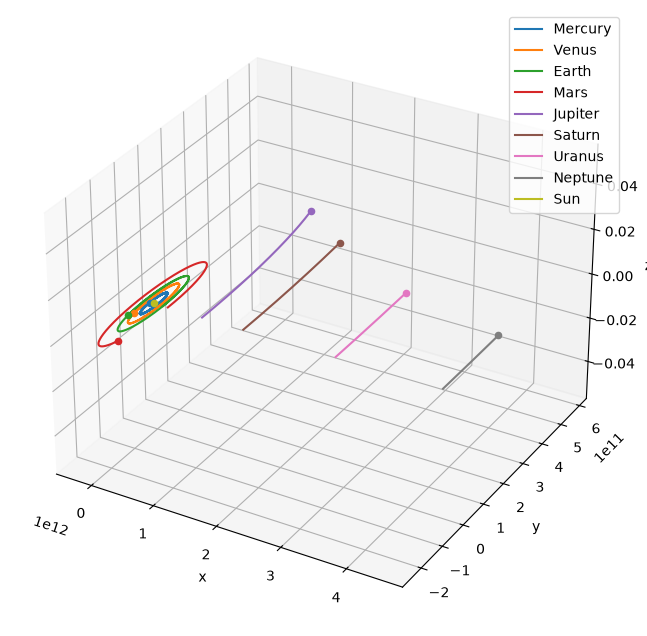

In [52]:
class SimulationRunner:

    sun = CelestialBody(1.989e30, np.array([0.0, 0.0, 0.0]), np.array([0.0, 0.0, 0.0]), name="Sun")

    allBodies = Planets().allPlanets.copy()
    allBodies.append(sun)

    simulation = NBodySimulation(bodies=allBodies)

    traj = simulation.Simulator(5000)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    for i, body in enumerate(simulation.bodies):
        ax.plot(
            traj[:, i, 0],
            traj[:, i, 1],
            traj[:, i, 2],
            label = body.name
        )

        # final pos
        ax.scatter(
            traj[-1, i, 0],
            traj[-1, i, 1],
            traj[-1, i, 2],
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend()

    plt.show()